# Exercício 4 — Hashtable com colisões e encadeamento por lista

**Henrique Goldstein Maluhy Mendes Amaral** · DR1_AT — Algoritmos e Estruturas de Dados · Infnet

Para rodar: **Ambiente de execução → Executar tudo**. O notebook é independente, não precisa de nenhum arquivo externo.

**Roteiro:** (1) `HashTableChained` com buckets em lista encadeada · (2) atualização sem duplicata · (3) redimensionamento e rehash, com teste de que nada se perde · (4) custo medido × fator de carga · (5) cenário adversarial · (6) casos de borda

In [1]:
import random

import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)

## 1. A implementação

**Decisões:**

- **Cada bucket é uma lista encadeada** de nós `(key, value, next)`. Um bucket vazio é só `None`.
- **Inserção no início do bucket:** depois de conferir que a chave não existe, o nó novo entra na frente — O(1), sem precisar andar até o fim.
- **Função hash própria:** para inteiros uso a própria chave (como na aula: `chave % tamanho`); para strings, um hash polinomial. Não uso o `hash()` do Python porque ele sorteia o hash de strings a cada execução, e aí a distribuição nos buckets mudaria toda vez que o notebook roda.
- **Limiar de fator de carga: 0,75.** Quando `quantidade / capacidade` passa disso, a capacidade **dobra** e todas as chaves são redistribuídas (rehash).
- **Chave ausente levanta `KeyError`**, como o dicionário do Python. Devolver `None` seria ambíguo, porque `None` pode ser um valor legítimo guardado na tabela.

A tabela guarda um contador de comparações feitas dentro dos buckets, para as medições.

In [2]:
class NoBucket:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.next = None


class HashTableChained:
    LIMIAR = 0.75

    def __init__(self, capacidade=8, redimensionar=True):
        self.capacidade = capacidade
        self.buckets = [None] * capacidade
        self.quantidade = 0
        self.redimensionar = redimensionar   # desligo só nos experimentos com fator de carga fixo
        self.comparacoes = 0
        self.historico = []                  # (capacidade antiga, nova, fator de carga no momento)

    def _funcao_hash(self, key):
        if isinstance(key, bool) or not isinstance(key, (int, str)):
            raise TypeError(f"tipo de chave não suportado: {type(key).__name__}")
        if isinstance(key, int):
            return key
        h = 0
        for caractere in key:              # hash polinomial: cada letra pesa pela posição
            h = (h * 31 + ord(caractere)) % (2**32)
        return h

    def _indice(self, key):
        return self._funcao_hash(key) % self.capacidade

    def fator_de_carga(self):
        return self.quantidade / self.capacidade

    def put(self, key, value):
        i = self._indice(key)
        atual = self.buckets[i]
        while atual is not None:
            self.comparacoes += 1
            if atual.key == key:
                atual.value = value        # chave já existe: só atualizo, não duplico
                return
            atual = atual.next
        novo = NoBucket(key, value)
        novo.next = self.buckets[i]        # entra no início do bucket
        self.buckets[i] = novo
        self.quantidade += 1
        if self.redimensionar and self.fator_de_carga() > self.LIMIAR:
            self._rehash()

    def get(self, key):
        atual = self.buckets[self._indice(key)]
        while atual is not None:
            self.comparacoes += 1
            if atual.key == key:
                return atual.value
            atual = atual.next
        raise KeyError(f"chave não encontrada: {key!r}")

    def delete(self, key):
        i = self._indice(key)
        anterior, atual = None, self.buckets[i]
        while atual is not None:
            self.comparacoes += 1
            if atual.key == key:
                if anterior is None:
                    self.buckets[i] = atual.next   # era o primeiro do bucket
                else:
                    anterior.next = atual.next     # pula o nó removido
                self.quantidade -= 1
                return atual.value
            anterior, atual = atual, atual.next
        raise KeyError(f"chave não encontrada: {key!r}")

    def __len__(self):
        return self.quantidade

    def _rehash(self):
        antigos = self.buckets
        self.historico.append((self.capacidade, self.capacidade * 2, self.fator_de_carga()))
        self.capacidade *= 2
        self.buckets = [None] * self.capacidade
        # cada nó vai para o bucket novo; reaproveito o próprio nó, sem criar outro
        for cabeca in antigos:
            atual = cabeca
            while atual is not None:
                proximo = atual.next
                i = self._indice(atual.key)
                atual.next = self.buckets[i]
                self.buckets[i] = atual
                atual = proximo

    def tamanhos_dos_buckets(self):
        tamanhos = []
        for cabeca in self.buckets:
            n, atual = 0, cabeca
            while atual is not None:
                n, atual = n + 1, atual.next
            tamanhos.append(n)
        return tamanhos

## 2. Funciona? Inserção, busca, atualização e remoção

In [3]:
tabela = HashTableChained()
tabela.put(11, "Alice")
tabela.put(45, "Paula")
tabela.put(58, "Helena")
tabela.put("curso", "Algoritmos")

assert tabela.get(11) == "Alice"
assert tabela.get("curso") == "Algoritmos"
assert len(tabela) == 4

# atualizar uma chave que já existe não cria outra entrada
tabela.put(11, "Alice Souza")
assert tabela.get(11) == "Alice Souza"
assert len(tabela) == 4

# remover
assert tabela.delete(45) == "Paula"
assert len(tabela) == 3
try:
    tabela.get(45)
except KeyError as erro:
    print(f"depois de remover, buscar a chave 45 dá: KeyError {erro}")

print("put, get, delete, __len__ e atualização conferidos")

depois de remover, buscar a chave 45 dá: KeyError 'chave não encontrada: 45'
put, get, delete, __len__ e atualização conferidos


## 3. Redimensionamento e rehash — nenhuma chave se perde

Insiro 10.000 chaves (metade inteiros, metade strings), registro cada redimensionamento e depois confiro **todas** as chaves.

In [4]:
tabela = HashTableChained()
esperado = {}      # dicionário do Python usado SÓ como gabarito do teste
for i in range(5000):
    tabela.put(i * 7, f"int-{i}")
    tabela.put(f"chave-{i}", i)
    esperado[i * 7] = f"int-{i}"
    esperado[f"chave-{i}"] = i

print(f"{len(tabela)} chaves, capacidade final {tabela.capacidade}, "
      f"fator de carga {tabela.fator_de_carga():.3f}\n")
print("redimensionamentos:")
for antiga, nova, fator in tabela.historico:
    print(f"  {antiga:>6} → {nova:>6} buckets   (fator de carga tinha chegado a {fator:.3f})")

# todas as chaves continuam acessíveis e com o valor certo
for chave, valor in esperado.items():
    assert tabela.get(chave) == valor
assert len(tabela) == len(esperado)

# reinserir tudo com valores novos não duplica nada
for chave in esperado:
    tabela.put(chave, "novo")
assert len(tabela) == len(esperado)
assert all(tabela.get(chave) == "novo" for chave in esperado)
print("\nas 10.000 chaves continuam acessíveis depois de todos os rehashes, e reinserir não duplica")

10000 chaves, capacidade final 16384, fator de carga 0.610

redimensionamentos:
       8 →     16 buckets   (fator de carga tinha chegado a 0.875)
      16 →     32 buckets   (fator de carga tinha chegado a 0.812)
      32 →     64 buckets   (fator de carga tinha chegado a 0.781)
      64 →    128 buckets   (fator de carga tinha chegado a 0.766)
     128 →    256 buckets   (fator de carga tinha chegado a 0.758)
     256 →    512 buckets   (fator de carga tinha chegado a 0.754)
     512 →   1024 buckets   (fator de carga tinha chegado a 0.752)
    1024 →   2048 buckets   (fator de carga tinha chegado a 0.751)
    2048 →   4096 buckets   (fator de carga tinha chegado a 0.750)
    4096 →   8192 buckets   (fator de carga tinha chegado a 0.750)
    8192 →  16384 buckets   (fator de carga tinha chegado a 0.750)

as 10.000 chaves continuam acessíveis depois de todos os rehashes, e reinserir não duplica


Assim que o fator de carga passa de 0,75, a capacidade dobra e ele cai para perto de 0,375. Com poucos buckets ele chega a passar um pouco do limiar antes do rehash (com 8 buckets, a 7ª chave já leva a 0,875), mas nas capacidades grandes fica colado em 0,750. Como a capacidade **dobra** (e não aumenta de um em um), o custo total dos rehashes é O(n): cada rehash custa o tamanho atual, e a soma `8 + 16 + 32 + ... + n` fica abaixo de `2n`. Por isso o `put` é **O(1) amortizado**.

## 4. Custo × fator de carga

Com encadeamento, o bucket de uma chave tem em média `α = n / m` elementos (`n` chaves, `m` buckets). A teoria diz:

- **busca com sucesso:** ≈ `1 + α/2` comparações (acho a chave, em média, na metade do bucket);
- **busca sem sucesso:** ≈ `α` comparações (percorro o bucket inteiro).

Para controlar o `α`, desligo o redimensionamento e uso capacidade fixa de 1.000 buckets, variando o número de chaves:

In [5]:
m = 1000
linhas = []
for n in [250, 500, 750, 1000, 2000, 4000, 8000]:
    tabela = HashTableChained(capacidade=m, redimensionar=False)
    chaves = random.sample(range(10**9), n)
    for chave in chaves:
        tabela.put(chave, None)

    tabela.comparacoes = 0
    for chave in chaves:
        tabela.get(chave)
    sucesso = tabela.comparacoes / n

    tabela.comparacoes = 0
    ausentes = random.sample(range(10**9, 2 * 10**9), 2000)   # nenhuma delas está na tabela
    for chave in ausentes:
        try:
            tabela.get(chave)
        except KeyError:
            pass
    sem_sucesso = tabela.comparacoes / len(ausentes)

    alfa = n / m
    linhas.append({
        "alfa": alfa,
        "sucesso_medido": sucesso, "sucesso_teoria (1 + α/2)": 1 + alfa / 2,
        "sem_sucesso_medido": sem_sucesso, "sem_sucesso_teoria (α)": alfa,
        "medido / teoria": sucesso / (1 + alfa / 2),
    })

custo = pd.DataFrame(linhas)
custo

,alfa,sucesso_medido,sucesso_teoria (1 + α/2),sem_sucesso_medido,sem_sucesso_teoria (α),medido / teoria
0,0.25,1.156000,1.125,0.2300,0.25,1.027556
1,0.50,1.250000,1.250,0.5360,0.50,1.000000
2,0.75,1.373333,1.375,0.7625,0.75,0.998788
3,1.00,1.469000,1.500,1.0030,1.00,0.979333
4,2.00,2.039000,2.000,1.9715,2.00,1.019500
5,4.00,2.983500,3.000,4.0360,4.00,0.994500
6,8.00,5.020625,5.000,7.9975,8.00,1.004125


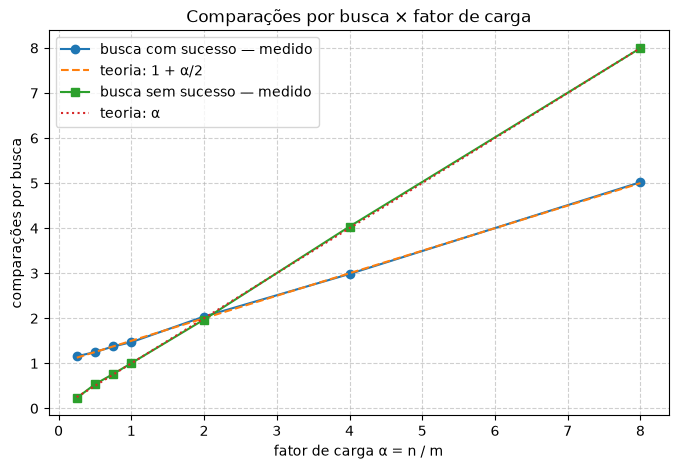

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(custo["alfa"], custo["sucesso_medido"], marker="o", label="busca com sucesso — medido")
plt.plot(custo["alfa"], custo["sucesso_teoria (1 + α/2)"], linestyle="--", label="teoria: 1 + α/2")
plt.plot(custo["alfa"], custo["sem_sucesso_medido"], marker="s", label="busca sem sucesso — medido")
plt.plot(custo["alfa"], custo["sem_sucesso_teoria (α)"], linestyle=":", label="teoria: α")
plt.title("Comparações por busca × fator de carga")
plt.xlabel("fator de carga α = n / m")
plt.ylabel("comparações por busca")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

Os pontos medidos caem **em cima das retas teóricas** (`medido / teoria` fica perto de 1,0 enquanto α cresce 32 vezes). Ou seja: o custo da busca **não** é "O(1)" incondicional — é **O(1 + α)**. Ele só é constante porque o redimensionamento segura `α ≤ 0,75`, o que dá no máximo cerca de 1,4 comparação por busca com sucesso.

## 5. Cenário adversarial: todas as chaves no mesmo bucket

"Hashtable é O(1)" vale **em média, se o hash espalhar as chaves**. Aqui eu quebro essa condição de propósito: escolho chaves que são **múltiplos de 1.024**. Como a capacidade é sempre uma potência de 2 (8, 16, ..., 1.024), todo múltiplo de 1.024 cai no bucket 0 — em **qualquer** dessas capacidades.

A consulta também é adversarial: busco uma chave ausente que **também** cai no bucket 0 (se eu buscasse uma chave qualquer, ela cairia num bucket vazio e o teste ia parecer ótimo).

In [7]:
n = 400
benignas = random.sample(range(10**9), n)
adversariais = [i * 1024 for i in range(n)]

resultados = []
for nome, chaves, ausente in [("benigno", benignas, 10**9 + 1), ("adversarial", adversariais, n * 1024)]:
    tabela = HashTableChained()
    for chave in chaves:
        tabela.put(chave, None)

    tabela.comparacoes = 0
    for chave in chaves:
        tabela.get(chave)
    por_busca = tabela.comparacoes / n

    tabela.comparacoes = 0
    try:
        tabela.get(ausente)
    except KeyError:
        pass

    tamanhos = tabela.tamanhos_dos_buckets()
    resultados.append({
        "cenario": nome, "capacidade_final": tabela.capacidade,
        "buckets_ocupados": sum(1 for t in tamanhos if t > 0),
        "maior_bucket": max(tamanhos),
        "comparacoes_por_busca_com_sucesso": por_busca,
        "busca_ausente": tabela.comparacoes,
        "busca_ausente / n": tabela.comparacoes / n,
    })

pd.DataFrame(resultados)

,cenario,capacidade_final,buckets_ocupados,maior_bucket,comparacoes_por_busca_com_sucesso,busca_ausente,busca_ausente / n
0,benigno,1024,334,3,1.18,0,0.0
1,adversarial,1024,1,400,200.50,400,1.0


- **Benigno:** as 400 chaves se espalham por centenas de buckets e cada busca custa perto de **1** comparação.
- **Adversarial:** as mesmas 400 chaves ficam **todas num único bucket**. A tabela virou uma lista encadeada: a busca com sucesso custa em média `(n+1)/2` e a busca de uma chave ausente custa **exatamente `n`** (`busca_ausente / n = 1,0`). Isso é **O(n)**.
- **Crescer não resolveu:** a tabela dobrou de 8 para 1.024 buckets durante o ataque. Não adianta, porque se dois números são congruentes módulo 1.024, também são congruentes módulo 8, 16, 32... As chaves continuam juntas em qualquer capacidade que seja potência de 2.

**Como se defende disso na prática:** usar uma função hash que o atacante não consiga prever (o Python faz isso com strings, sorteando o hash a cada execução — justamente o que eu desliguei aqui para ter reprodutibilidade), ou usar um número primo como capacidade, o que quebra esse padrão específico de múltiplos.

## 6. Casos de borda

In [8]:
tabela = HashTableChained()
assert len(tabela) == 0

# chave ausente em tabela vazia
for operacao in (tabela.get, tabela.delete):
    try:
        operacao("nada")
        raise AssertionError("deveria ter levantado KeyError")
    except KeyError:
        pass

# None como valor é permitido e não se confunde com "não achei"
tabela.put("vazio", None)
assert tabela.get("vazio") is None and len(tabela) == 1

# remover o primeiro, o do meio e o último de um mesmo bucket
tabela = HashTableChained(capacidade=4, redimensionar=False)
for chave in [0, 4, 8, 12]:          # todas caem no bucket 0
    tabela.put(chave, chave)
assert tabela.tamanhos_dos_buckets()[0] == 4
tabela.delete(12)                    # o primeiro do bucket (inserção é no início)
tabela.delete(4)                     # um do meio
tabela.delete(0)                     # o último
assert tabela.get(8) == 8 and len(tabela) == 1

# chaves negativas e strings vazias funcionam
tabela.put(-5, "negativo")
tabela.put("", "string vazia")
assert tabela.get(-5) == "negativo" and tabela.get("") == "string vazia"

# tipo de chave não suportado é recusado com mensagem clara
try:
    tabela.put([1, 2], "lista")
except TypeError as erro:
    print(f"chave inválida → {erro}")

print("todos os casos de borda passaram")

chave inválida → tipo de chave não suportado: list
todos os casos de borda passaram


## Resumo

| operação | caso médio | pior caso (todas no mesmo bucket) |
|---|---|---|
| `put` | O(1) amortizado | O(n) |
| `get` | O(1 + α) | O(n) |
| `delete` | O(1 + α) | O(n) |
| `__len__` | O(1) | O(1) |
| rehash | O(n), mas raro: O(1) amortizado por inserção | O(n) |

O "O(1)" da hashtable é uma **promessa condicional**: depende do fator de carga ficar controlado (o rehash garante isso) e do hash espalhar as chaves (o cenário adversarial mostra o que acontece quando não espalha).